In [9]:
import warnings

warnings.filterwarnings('ignore')
import torch

dtype = torch.float
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
import matplotlib.pyplot as plt
import numpy as np
from tifffile import imread

import json
import os
from datetime import datetime
from pathlib import Path

from lisai.lib.hdn import histNoiseModel
from lisai.lib.hdn.gaussianMixtureNoiseModel import GaussianMixtureNoiseModel
from lisai.lib.hdn.utils import plotProbabilityDistribution
from lisai.data.utils import crop_center

In [10]:
### DEFINE PARAMETERS ###

# Data paths
baseDir = Path(r"E:\dl_monalisa")
dataDir = baseDir / "Data"
noiseModelsDir = baseDir / "noiseModels"

dataset = "Mito_fixed"
data_path_signal = dataDir / dataset / r"preprocess\recon\gt_avg\train" #r"inference\N2V\Vim_fixed_OnInpSingle_mse"
data_path_obs = dataDir / dataset / r"preprocess\recon\inp_mltpl_snr\train" # or "same"

# Parameters
noise_level = 9 # list of int for mltpl noise, or int
signalIdx = None

createAvgSig = False # to create avg signal on the fly
createAvgSig_nFrames = 3 # int or "all"

normSig2Obs = True
normalizeEverything = True
clip = -3 # False or clip value
crop_size = (1200,1200)
display = True # display images and histograms or not
hist_bins = 256

# Saving names
overwrite = False
sigInfo = "SnrAvg" #how signal was generated info, eg. "n2v" or "avg5" or "bootstrapped"
noise_level_str = ''.join(str(noise_level).split(', '))[1:-1] if isinstance(noise_level,list) else noise_level
norm_str = "norm" if normalizeEverything else "noNorm"
saveName = f"{dataset}_Noise{noise_level_str}_Sig{sigInfo}_Clip{clip}_{norm_str}"
nameHistNoiseModel = "Histogram"
nameGMMNoiseModel = "/GMM"
saveDir = noiseModelsDir / saveName

# Create saving directory
if os.path.exists(saveDir):
    if overwrite == True:
        warnings.warn("Saving directory already exists, overwriting")
    else:
        i = 0
        for i in range(11):
            
            if i == 10:
                raise Exception("Saving name too repetitive, 10 noise models with same name already exist!")
            
            newPath = Path(str(saveDir) + f"_{i}")
            if os.path.exists(newPath):
                i += 1
                continue
            else:
                os.makedirs(newPath)
                saveDir = newPath
                break
else:
    os.makedirs(saveDir)

if isinstance(noise_level,int):
    mltpl_noise = False
else:
    mltpl_noise = True
    nNoise = len(noise_level)

print(f"Dataset: {dataset}")
print(f"Noise level: {noise_level}")
print(f"Saving at: {saveDir}")

Dataset: Mito_fixed
Noise level: 9
Saving at: E:\dl_monalisa\noiseModels\Mito_fixed_Noise9_SigSnrAvg_Clip-3_norm


In [11]:
### LOAD DATA ###

signal = []
observation = []
filters = ['tif','tiff']

files_signal = os.listdir(data_path_signal)
for f in files_signal:
    if f.split('.')[-1] not in filters:
        print(f"removing {f} in signals because not in filters")
        files_signal.remove(f)

if data_path_obs != "same":
    files_obs = os.listdir(data_path_obs)
    for f in files_obs:
        if f.split('.')[-1] not in filters:
            print(f"Removing {f} in observations because not in filters")
            files_obs.remove(f)

    assert len(files_obs) == len(files_signal)
    print(f"\nFound {len(files_signal)} files.\n")
else:
    files_obs = files_signal
    data_path_obs = data_path_signal

for i in range (len(files_signal)):
    file_signal = files_signal[i]
    if data_path_obs == "same":
        file_obs = file_signal
    else:
        file_obs = files_obs [i]
    
    # signal idx selection (if applicable)
    if not createAvgSig:
        if isinstance(signalIdx,int):
            im_signal = imread(data_path_signal / file_signal)[signalIdx]
        else:
            im_signal = imread(data_path_signal / file_signal)
    else:
        im_signal = imread(data_path_signal / file_signal)
        assert len(im_signal.shape) == 3, "Create avg signal impossible if signal not 3D stack!"
        im_signal = np.mean(im_signal[:min(im_signal.shape[0],createAvgSig_nFrames)],axis=0)
        
    # noise level selection
    try:
        im_obs = imread(data_path_obs / file_obs)[noise_level]
    except IndexError:
        print(f"Image {f} ignored because of IndexError") 
        continue

    if not isinstance(clip,bool):
        im_obs[im_obs<clip] = clip
        im_signal[im_signal<clip] = clip

    if crop_size is not None:
        im_obs = crop_center(im_obs,crop_size)
        im_signal = crop_center(im_signal,crop_size)
        if im_signal.shape!=crop_size:
            continue

    observation.append(im_obs)
    signal.append(im_signal)

    print(f"Signal {file_signal}: Observation {file_obs}:\t Shape: {im_obs.shape}")

if not mltpl_noise:
    signal = np.stack(signal)
    observation = np.stack(observation)
    if normSig2Obs:
        signal = (signal - np.mean(signal)) / np.std(signal)
        signal = signal * np.std(observation) + np.mean(observation)
elif not normSig2Obs:
    signal = np.repeat(np.stack(signal),nNoise,axis=0)
    observation = np.concatenate(observation)
else:
    h,w = observation[0].shape[-2:]
    nImgs = len(signal)
    observation = np.reshape(np.concatenate(observation),(nNoise,nImgs,h,w),order='F')
    avgObs_per_noise = np.mean(observation,axis=(1,2,3))
    stdObs_per_noise = np.std(observation,axis=(1,2,3))

    signal = np.stack(signal)
    signal = (signal - np.mean(signal)) / np.std(signal)
    signal = np.tile(signal,(nNoise,1,1,1))
    signal = signal * stdObs_per_noise[:, np.newaxis, np.newaxis, np.newaxis] + avgObs_per_noise[:, np.newaxis, np.newaxis, np.newaxis]
    
    observation = np.reshape(observation,(nNoise*nImgs,h,w))
    signal = np.reshape(signal,(nNoise*nImgs,h,w))

# fullSig = []
# fullObs = []
# for i,obs in enumerate(observation):
#     sig = signal[i]
#     norm_sig = (sig - np.mean(sig))/np.std(sig)
#     for frame in obs:
#         if normSig2Obs:
#             fullSig.append(norm_sig * np.std(frame) + np.mean(frame))
#         else:
#             fullSig.append(sig)
#         fullObs.append(frame)

avgObs = np.mean(observation)
stdObs = np.std(observation)
avgSig = np.mean(signal)
stdSig = np.std(signal)

if normalizeEverything:
    signal = (signal - np.mean(signal))/np.std(signal)
    observation = (observation - np.mean(observation))/np.std(observation)

minVal = np.min(signal)
maxVal = np.max(signal)

print(minVal,maxVal)

print(f"\n\nConcatenated arrays: Signal: {signal.shape} Observation: {observation.shape}")



Found 18 files.

Signal c00.tif: Observation c00.tif:	 Shape: (1200, 1200)
Signal c03.tif: Observation c03.tif:	 Shape: (1200, 1200)
Signal c04.tif: Observation c04.tif:	 Shape: (1200, 1200)
Signal c05.tif: Observation c05.tif:	 Shape: (1200, 1200)
Signal c06.tif: Observation c06.tif:	 Shape: (1200, 1200)
Signal c07.tif: Observation c07.tif:	 Shape: (1200, 1200)
Signal c09.tif: Observation c09.tif:	 Shape: (1200, 1200)
Signal c12.tif: Observation c12.tif:	 Shape: (1200, 1200)
Signal c13.tif: Observation c13.tif:	 Shape: (1200, 1200)
Signal c14.tif: Observation c14.tif:	 Shape: (1200, 1200)
Signal c15.tif: Observation c15.tif:	 Shape: (1200, 1200)
Signal c17.tif: Observation c17.tif:	 Shape: (1200, 1200)
Signal c18.tif: Observation c18.tif:	 Shape: (1200, 1200)
Signal c19.tif: Observation c19.tif:	 Shape: (1200, 1200)
Signal c22.tif: Observation c22.tif:	 Shape: (1200, 1200)
Signal c24.tif: Observation c24.tif:	 Shape: (1200, 1200)
Signal c26.tif: Observation c26.tif:	 Shape: (1200, 12

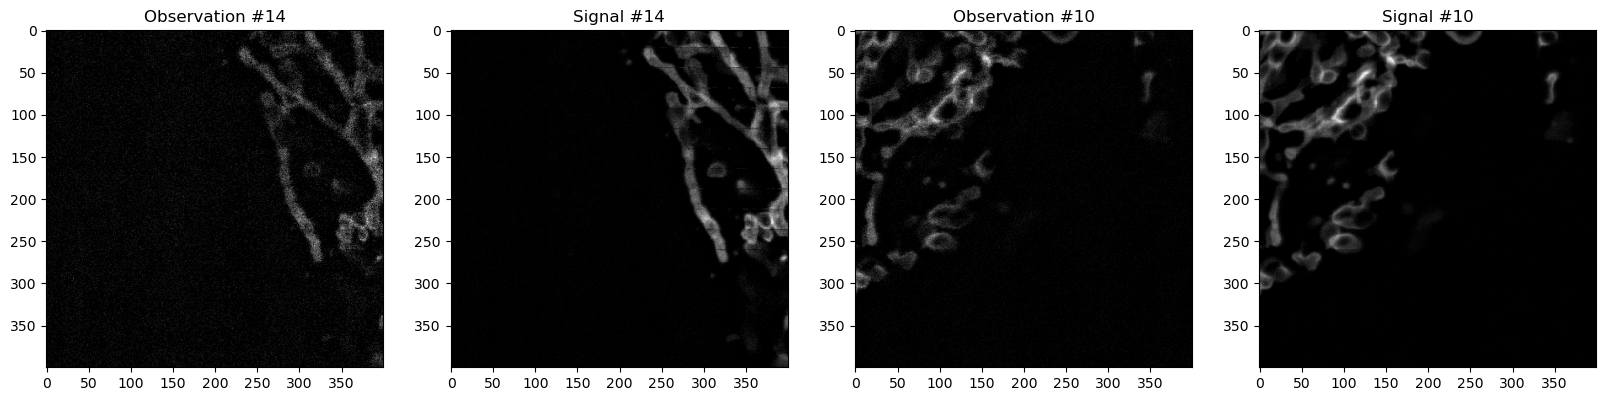

In [13]:
# Display examples of signals and observations if display is set to True

display_crop_size = 400
if display:
    idxs = np.random.randint(0,observation.shape[0],2)
    plt.figure(figsize=(20,10))
    for i in range(len(idxs)):
        sig = crop_center(signal[idxs[i]],display_crop_size)
        obs = crop_center(observation[idxs[i]],display_crop_size)
        plt.subplot(1,4,2*i+1)
        plt.imshow(obs,cmap="gray")
        plt.title(f"Observation #{idxs[i]}")
        plt.subplot(1,4,2*i+2)
        plt.imshow(sig,cmap="gray")
        plt.title(f"Signal #{idxs[i]}")

Hist noise model saved at E:\dl_monalisa\noiseModels\Mito_fixed_Noise9_SigSnrAvg_Clip-3_norm\Histogram


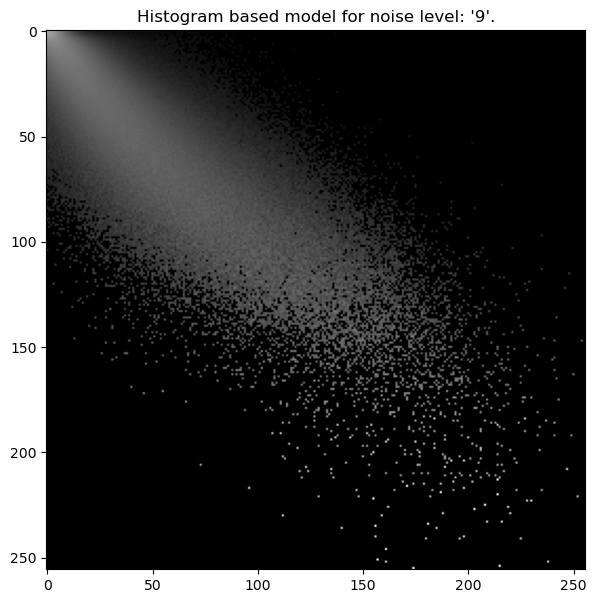

In [14]:
# Create, save and display histogram-based model

plt.figure(figsize=(7,7))
histogram = histNoiseModel.createHistogram(hist_bins, minVal, maxVal, observation,signal)

# Saving histogram
save_path = os.path.join(saveDir, nameHistNoiseModel)
np.save(save_path, histogram)
print(f"Hist noise model saved at {save_path}")

# Optional display
if display:
    plt.title(f"Histogram based model for noise level: '{noise_level}'.")
    plt.imshow(histogram[0]**0.25, cmap='gray')
    plt.show()


In [18]:
# Training GMM noise model
n_gaussian = 5# Number of gaussians to use for Gaussian Mixture Model
n_coeff = 4# No. of polynomial coefficients for parameterizing the mean, standard deviation and weight of Gaussian components.
n_epochs = 3000
lr = 0.05

gaussianMixtureNoiseModel = GaussianMixtureNoiseModel(min_signal = minVal,
                                                    max_signal = maxVal,
                                                    path=str(saveDir), weight = None, 
                                                    n_gaussian = n_gaussian,
                                                    n_coeff = n_coeff,
                                                    min_sigma = 1, 
                                                    device = device)

gaussianMixtureNoiseModel.train(signal, observation, batchSize = 250000, n_epochs = n_epochs, learning_rate=lr, name = nameGMMNoiseModel)

0 1.280102014541626
100 1.1247941255569458
200 1.124140739440918
300 1.1258033514022827
400 1.1218379735946655
500 1.1225314140319824
600 1.1214816570281982
700 1.1214770078659058
800 1.1220412254333496
900 1.1210243701934814
1000 1.1217190027236938
1100 1.121325969696045
1200 1.121539831161499
1300 1.1218860149383545
1400 1.1202207803726196
1500 1.1209532022476196
1600 1.1189782619476318
1700 1.119344711303711
1800 1.1195094585418701
1900 1.120648741722107
2000 1.119415044784546
2100 1.1203707456588745
2200 1.1186920404434204
2300 1.1188547611236572
2400 1.1198010444641113
2500 1.119914174079895
2600 1.118430733680725
2700 1.119189739227295
2800 1.1186007261276245
2900 1.1181468963623047

The trained parameters (/GMM) is saved at location: E:\dl_monalisa\noiseModels\Mito_fixed_Noise9_SigSnrAvg_Clip-3_norm


In [19]:
#### SAVING INFO ####

# norm_prm saving

norm_prm = {
    "clip": clip,
    "normalize_data": normalizeEverything,
    "normSig2Obs": normSig2Obs,
    "avgObs": avgObs.item(),
    "stdObs": stdObs.item(),
    "avgSig": avgSig.item(),
    "stdSig": stdSig.item(),
}

if mltpl_noise and normSig2Obs:
    norm_prm["avgObs_per_noise"] = avgObs_per_noise.tolist()
    norm_prm["stdObs_per_noise"] = stdObs_per_noise.tolist()

with open(saveDir / "norm_prm.json", 'w') as norm_file: 
    norm_file.write(json.dumps(norm_prm,indent=4))   

# Save other parameters into txt file
now = datetime.now() 
dt_string = now.strftime("%d/%m/%Y - %Hh%Mm%Ss")
header = f"{dt_string}\nNoise Model Info\n\n"

if createAvgSig:
    sigInfo = f"Average first #{createAvgSig_nFrames} frames"
else:
    sigInfo = f"Used frame idx {signalIdx}"

params = (f"Dataset: {dataset}\n"
        f"\n"
        f"Noisy data path: {data_path_signal}\n"
        f"Signal data path: {data_path_obs}\n"
        f"Noise Level: {noise_level}\n"
        f"Signal: {sigInfo}\n"
        f"\n"
        f"Clip: {clip}\n"
        f"Normalized signal to observation: {normSig2Obs}\n"
        f"Normalized everything: {normalizeEverything}\n"
        f"Mean(obs): {avgObs}\n"
        f"Std(obs): {stdObs}\n"
        f"Mean(sig): {avgSig}\n"
        f"Std(sig): {stdSig}\n"
        f"\n"
        f"Histogram bins: {hist_bins}\n"
        f"Crop Size: {crop_size}\n"
        f"GMM parameters: #{n_gaussian} gaussian, #{n_coeff} coeff\n"
        f"GMM training params: #{n_epochs}, learning rate {lr}"
    )

txtPath = saveDir / "info.txt"
with open(txtPath,"w") as f:
    f.write(header)
    f.write(params)

E:\dl_monalisa\noiseModels\Mito_fixed_Noise9_SigSnrAvg_Clip-3_norm


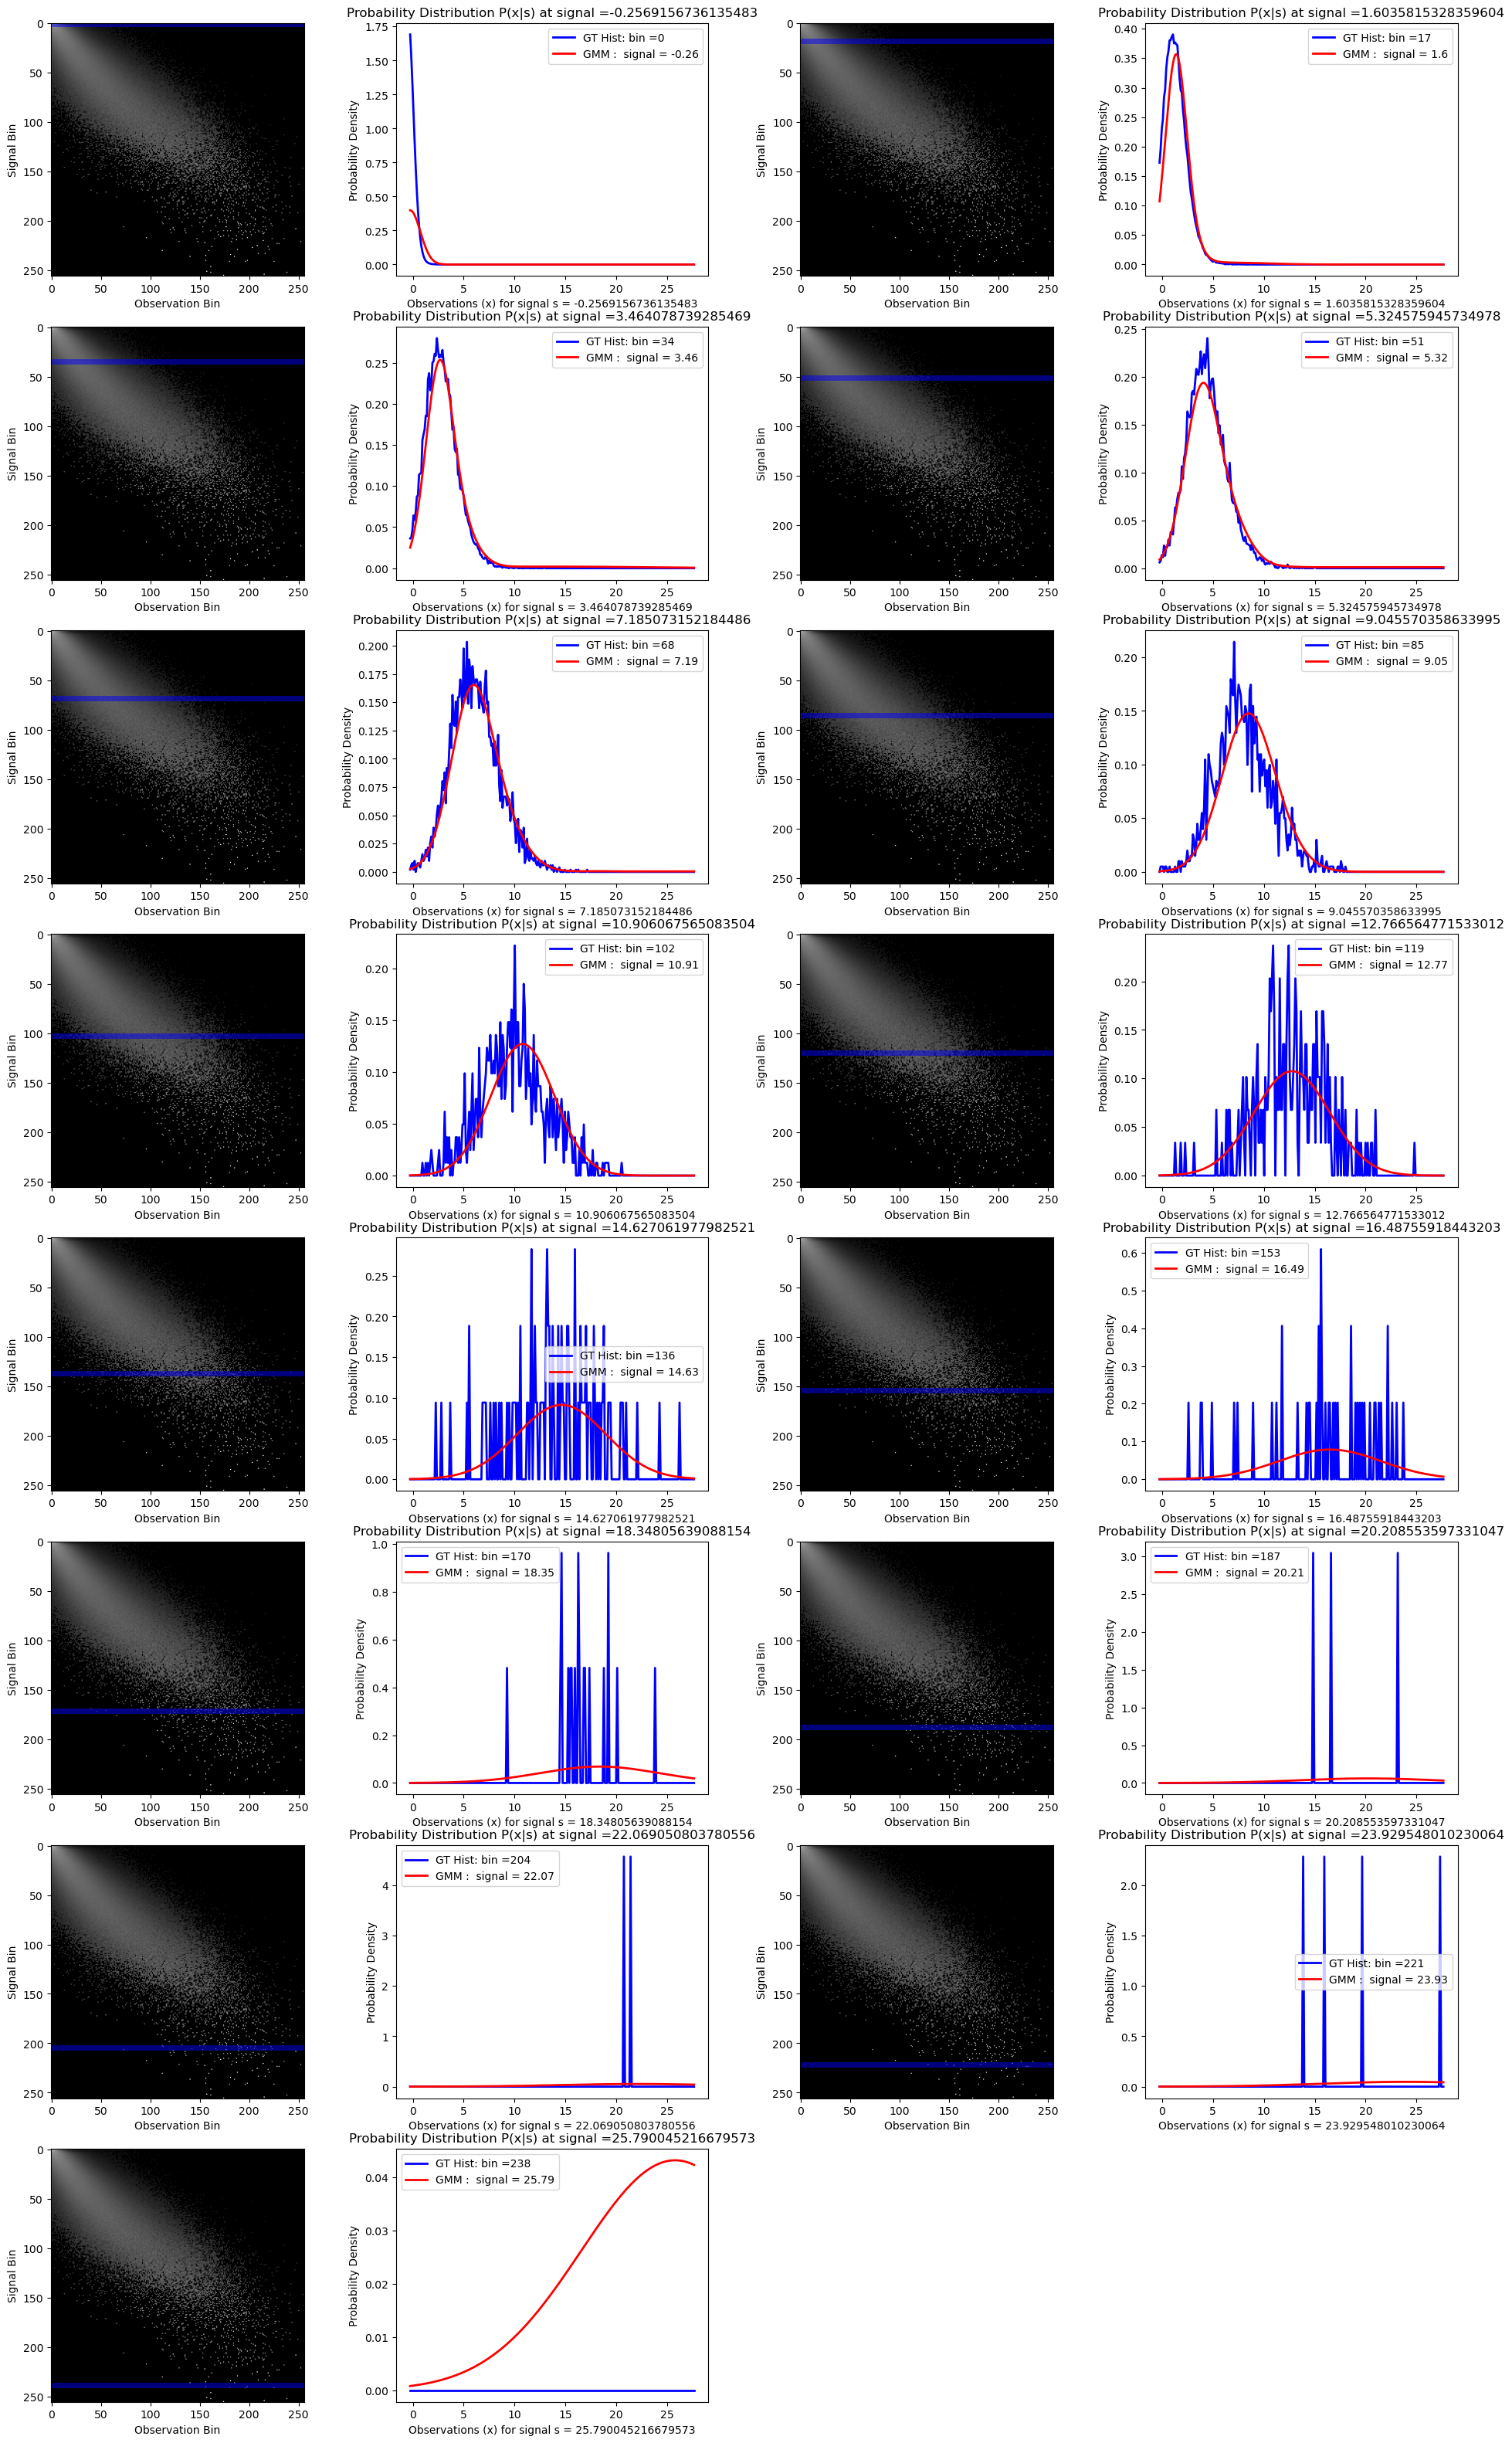

In [20]:
# Check GMM perf
GMMname = nameGMMNoiseModel[1::]+".npz" # to check current one
# GMMname = "GMM_Noiseall_SigAVG_Clip-3_nGauss5_nCoeff6.npz"# to check existing one

n_points = 15
signalBinIndex_list = (np.linspace(0,n_points-1,n_points)*hist_bins//n_points).astype(int).tolist()
GMMmodel_prm = np.load(os.path.join(noiseModelsDir,saveDir,GMMname))
print(saveDir)
GMMmodel = GaussianMixtureNoiseModel(params = GMMmodel_prm, device = device) 

fig=plotProbabilityDistribution(signalBinIndex=signalBinIndex_list, histogram=histogram[0], gaussianMixtureNoiseModel=GMMmodel, 
                                min_signal=minVal, max_signal=maxVal, n_bin=hist_bins, device=device,max_columns=4)
plt.savefig(saveDir/"GMM_plot.png")
plt.savefig(saveDir/"GMM_plot.svg")